Data updated on 31. August 2024

In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objs as go

In [131]:
df_sent = pd.read_csv(r'/Users/nikitapiko/Documents/University/WU Wien/SBWL/Data Science/PROJECTS/SPX500/nlp/spx_headlines_w_sent_feb2026.csv', sep=';')

In [132]:
df_sent

,headline,date,source,finbert_sentiment,logreg_sentiment
0,"Wall Street ends higher, lifted by Nvidia and ...",2026-02-18,Reuters,Positive,Negative
1,Wall Street ends down as Nvidia slides and pri...,2026-02-19,Reuters,Neutral,Negative
2,Wall Street ends higher after Supreme Court ru...,2026-02-20,Reuters,Neutral,Negative
3,Wall Street ends sharply lower amid AI displac...,2026-02-23,Reuters,Negative,Negative
4,"Wall St bounces back, ending higher on renewed...",2026-02-24,Reuters,Positive,Negative
...,...,...,...,...,...
304,Stocks edge higher on optimism about AI demand,2026-02-16,Yahoo Finance,Positive,Positive
305,Wall Street mixed as investors monitor economi...,2026-02-17,Yahoo Finance,Neutral,Neutral
306,S&P 500 rises as semiconductor stocks rally,2026-02-18,Yahoo Finance,Positive,Positive
307,Stocks dip as investors weigh energy price surge,2026-02-19,Yahoo Finance,Negative,Positive


In [133]:
df_sent['date']=pd.to_datetime(df_sent['date']).dt.strftime('%Y-%m-%d')

In [134]:
def create_daily_indicator(df, sentiment_col):
    rows=[]
    for date,group in df.groupby('date'):
        sent_counts = group[sentiment_col].value_counts()

        pos = sent_counts.get('Positive', 0)
        neu = sent_counts.get('Neutral', 0)
        neg = sent_counts.get('Negative', 0)

        total = neg + neu + pos

        if total == 0:
            sent_val = 0
        else: 
            sent_val = (pos - neg) / total

        sent_val_100scale = ((sent_val + 1) / 2) * 100

        rows.append({'date': date,
                    "positive": pos,
                    "neutral": neu,
                    "negative": neg,
                    "sentiment_value": sent_val,
                    "headline_sentiment": sent_val_100scale
                    })
    return pd.DataFrame(rows).sort_values('date')

In [135]:
# get daily indicator values
finbert_ind = create_daily_indicator(df_sent, 'finbert_sentiment')

In [136]:
finbert_ind

,date,positive,neutral,negative,sentiment_value,headline_sentiment
0,2026-02-01,9,0,4,0.384615,69.230769
1,2026-02-02,5,1,5,0.000000,50.000000
2,2026-02-03,2,2,8,-0.500000,25.000000
3,2026-02-04,8,3,2,0.461538,73.076923
4,2026-02-05,3,2,6,-0.272727,36.363636
5,2026-02-06,13,0,0,1.000000,100.000000
6,2026-02-07,6,3,5,0.071429,53.571429
7,2026-02-08,4,5,3,0.083333,54.166667
8,2026-02-09,8,0,5,0.230769,61.538462
9,2026-02-10,0,5,9,-0.642857,17.857143


In [137]:
finbert_ind.to_csv(r'/Users/nikitapiko/Documents/University/WU Wien/SBWL/Data Science/PROJECTS/SPX500/data/mix_headlines_w_sent_indicator.csv', index=False)

In [138]:
# this cnn fear and greed index data has been collected manually since scraping was blocked due to bot blockers
recorded_cnn_fear_and_greed_values_feb = [
{'date': '2026-02-02', 'cnn_fear_greed_sentiment': 50, 'cnn_fear_greed_rating': 'neutral'},
{'date': '2026-02-03', 'cnn_fear_greed_sentiment': 44, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-04', 'cnn_fear_greed_sentiment': 40, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-05', 'cnn_fear_greed_sentiment': 34, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-06', 'cnn_fear_greed_sentiment': 44, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-09', 'cnn_fear_greed_sentiment': 49, 'cnn_fear_greed_rating': 'neutral'},
{'date': '2026-02-10', 'cnn_fear_greed_sentiment': 51, 'cnn_fear_greed_rating': 'neutral'},
{'date': '2026-02-11', 'cnn_fear_greed_sentiment': 48, 'cnn_fear_greed_rating': 'neutral'},
{'date': '2026-02-12', 'cnn_fear_greed_sentiment': 36, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-13', 'cnn_fear_greed_sentiment': 36, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-17', 'cnn_fear_greed_sentiment': 38, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-18', 'cnn_fear_greed_sentiment': 39, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-19', 'cnn_fear_greed_sentiment': 37, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-20', 'cnn_fear_greed_sentiment': 44, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-23', 'cnn_fear_greed_sentiment': 37, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-24', 'cnn_fear_greed_sentiment': 43, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-25', 'cnn_fear_greed_sentiment': 46, 'cnn_fear_greed_rating': 'neutral'},
{'date': '2026-02-26', 'cnn_fear_greed_sentiment': 42, 'cnn_fear_greed_rating': 'fear'},
{'date': '2026-02-27', 'cnn_fear_greed_sentiment': 38, 'cnn_fear_greed_rating': 'fear'}
]

In [139]:
df_cnn = pd.DataFrame(recorded_cnn_fear_and_greed_values_feb)

In [140]:
df_cnn['date'] = pd.to_datetime(df_cnn['date']).dt.strftime('%Y-%m-%d')

In [141]:
finbert_ind_vs_cnn = finbert_ind.merge(df_cnn, how='inner', on='date')

Correlation between FinBERT sentiment and CNN Fear & Greed: 0.10829656619847658


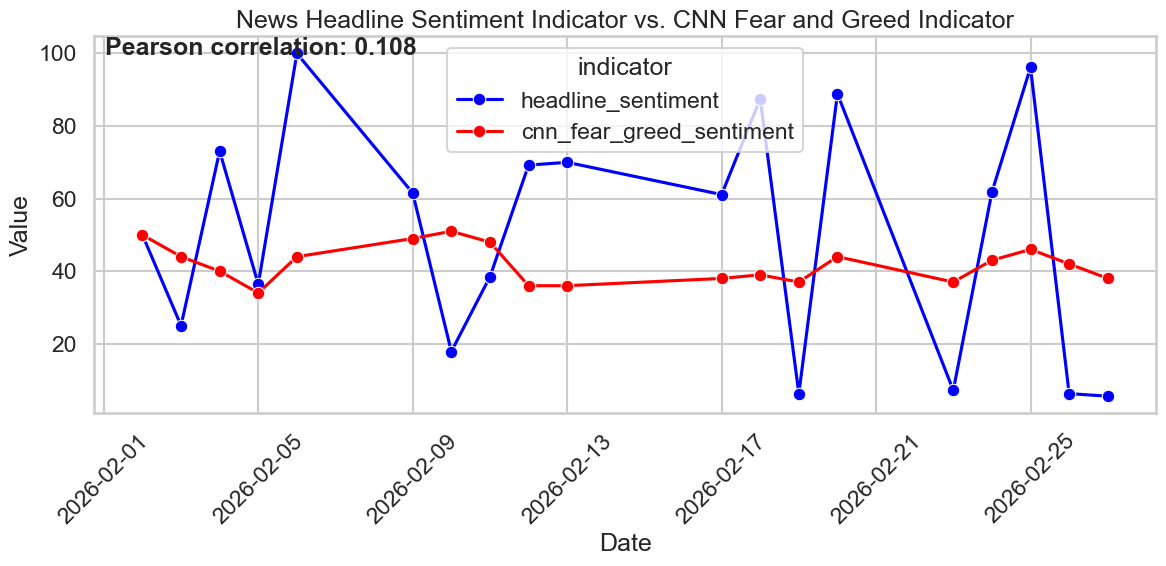

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

finbert_ind_vs_cnn["date"] = pd.to_datetime(finbert_ind_vs_cnn["date"])

# remove rows without CNN values
plot_df = finbert_ind_vs_cnn.dropna(subset=["cnn_fear_greed_sentiment"])

# correlation
corr = plot_df["headline_sentiment"].corr(plot_df["cnn_fear_greed_sentiment"])
print("Correlation between FinBERT sentiment and CNN Fear & Greed:", corr)

# reshape for seaborn
plot_df_melt = plot_df.melt(
    id_vars="date",
    value_vars=["headline_sentiment", "cnn_fear_greed_sentiment"],
    var_name="indicator",
    value_name="value"
)

# plot aggregated sentiments
plt.figure(figsize=(12,6))
sns.lineplot(
    data=plot_df_melt,
    x="date",
    y="value",
    hue="indicator",
    marker="o",
    palette={
        "headline_sentiment": "blue",
        "cnn_fear_greed_sentiment": "red"
    }
)

plt.title("News Headline Sentiment Indicator vs. CNN Fear and Greed Indicator")
plt.xlabel("Date")
plt.ylabel("Value")

# add Pearson correlation on plot
plt.text(
    0.01, 0.95,
    f"Pearson correlation: {corr:.3f}",
    transform=plt.gca().transAxes,
    fontweight = 'bold'
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

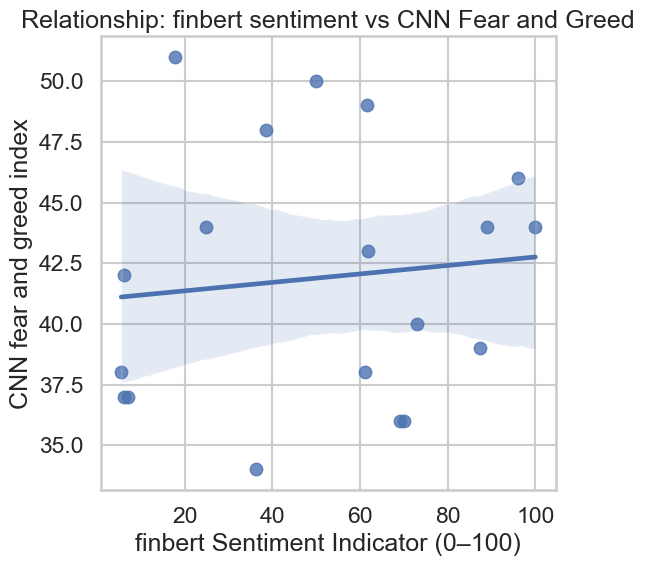

In [145]:
# plotting the comparisono between both idnicators

plt.figure(figsize=(6,6))
sns.regplot(
    data=plot_df,
    x="headline_sentiment",
    y="cnn_fear_greed_sentiment"
)

plt.title("Relationship: finbert sentiment vs CNN Fear and Greed")

plt.xlabel("finbert Sentiment Indicator (0–100)")
plt.ylabel("CNN fear and greed index")
plt.tight_layout()
plt.show()

In [63]:
corr = finbert_ind_vs_cnn["sentiment_indicator_100scale"].corr(finbert_ind_vs_cnn["cnn_fear_greed_score"])

print(round(corr, 2))

0.11
